In [1]:
import os
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from unidecode import unidecode
from pandas.plotting import scatter_matrix

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    cross_val_score, cross_val_predict,
    GridSearchCV, RandomizedSearchCV,
    KFold,
)

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [2]:
epl_stats = pd.read_csv("Original Data/epl_original_data.csv")
fpl_stats = pd.read_csv("Original Data/fpl_original_data.csv")

# EPL: split full name to first + last only, strip accents
epl_split = epl_stats["full_name"].str.split()
epl_stats = epl_stats.assign(
    first_name=epl_split.str[0],
    second_name=epl_split.str[-1],
)
epl_stats["full_name"] = (
    epl_stats["first_name"] + " " + epl_stats["second_name"]
).apply(unidecode)

# FPL: same normalisation
fpl_stats = fpl_stats.assign(
    first_name=fpl_stats["first_name"].str.split().str[0],
    second_name=fpl_stats["second_name"].str.split().str[-1],
)
fpl_stats["full_name"] = (
    fpl_stats["first_name"] + " " + fpl_stats["second_name"]
).apply(unidecode)

print(f"EPL rows: {len(epl_stats)}  |  FPL rows: {len(fpl_stats)}")

EPL rows: 570  |  FPL rows: 624


In [3]:
# Filter to players with meaningful playing time
fpl_stats = fpl_stats[fpl_stats["minutes"] >= 500].copy()
epl_stats = epl_stats[epl_stats["minutes_played_overall"] >= 500].copy()

# Merge FPL and EPL
final_dataset = pd.merge(fpl_stats, epl_stats, how="left", on="full_name")

# Persist for reference
os.makedirs("Data", exist_ok=True)
final_dataset.to_csv("Data/final_dataset.csv", index=False)

print(f"Merged dataset: {final_dataset.shape[0]} players, {final_dataset.shape[1]} columns")
final_dataset.describe()

Merged dataset: 384 players, 297 columns


,goals_scored,assists,total_points,minutes,goals_conceded,creativity,influence,threat,bonus,bps,...,annual_salary_eur_percentile,clean_sheets_percentage_percentile_overall,min_per_card_percentile_overall,cards_per90_percentile_overall,booked_over05_overall,booked_over05_percentage_overall,booked_over05_percentage_percentile_overall,shirt_number,annual_salary_gbp,annual_salary_usd
count,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,384.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,2.640625,2.361979,78.080729,1894.708333,29.609375,282.613542,437.570833,316.700521,6.195312,348.559896,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3.975909,2.901645,46.340112,856.276393,15.369038,272.805555,253.844207,344.410938,6.512962,191.905102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,8.000000,511.000000,3.000000,0.000000,40.000000,0.000000,0.000000,29.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,0.000000,44.000000,1086.250000,17.000000,82.975000,226.350000,85.000000,1.000000,191.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.000000,1.000000,69.000000,1887.500000,27.500000,204.250000,399.900000,204.000000,4.000000,318.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3.000000,3.000000,101.250000,2591.500000,40.250000,395.975000,607.800000,405.000000,9.000000,475.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,22.000000,15.000000,259.000000,3420.000000,78.000000,1515.000000,1306.200000,2168.000000,35.000000,932.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# column correlation to total_points
# Drop all null columns first 
dataset_clean = final_dataset.dropna(how="all", axis="columns")

corr = dataset_clean.corr(numeric_only=True)
corr["total_points"].sort_values(ascending=False).iloc[1:16]

bps                       0.881036
bonus                     0.875851
influence                 0.864184
ict_index                 0.857319
clean_sheets              0.816797
minutes                   0.781988
appearances_overall       0.778631
minutes_played_overall    0.774875
selected_by_percent       0.772443
minutes_played_home       0.766172
appearances_away          0.761062
minutes_played_away       0.751635
appearances_home          0.747261
clean_sheets_overall      0.741637
clean_sheets_home         0.705606
Name: total_points, dtype: float64

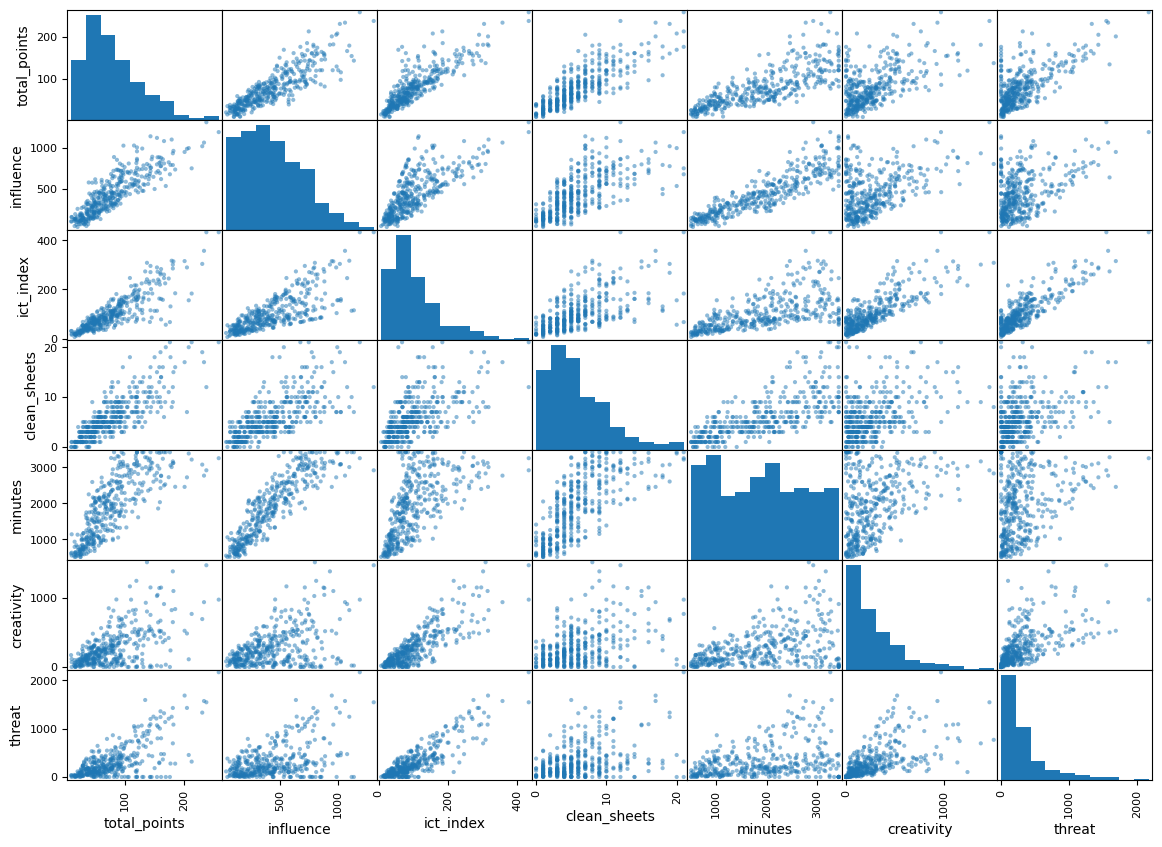

In [5]:
# scatter matrix for top correlated features

eda_cols = ["total_points", "influence", "ict_index", "clean_sheets", "minutes", "creativity", "threat"]
scatter_matrix(dataset_clean[eda_cols], figsize=(14, 10));


In [6]:
TARGET = "total_points"

# Columns to exclude from features:
#   - identifiers / metadata
#   - bps & bonus: accumulated post-game points that have direct relation to total_points
#   - influence & ict_index: derived metric from raw data being used to predict score such as goals, assists, clean sheets
DROP_COLS = [
    "birthday", "birthday_GMT", "league", "season",
    "first_name_x", "second_name_x", "first_name_y", "second_name_y",
    "full_name",
    "bps", "bonus",
    "influence", "ict_index",
]

feature_df = dataset_clean.drop(
    columns=[c for c in DROP_COLS if c in dataset_clean.columns]
)

X = feature_df.drop(columns=[TARGET])
y = feature_df[TARGET]

CAT_COLS = ["Current Club", "position", "nationality"]
NUM_COLS = [c for c in X.columns if c not in CAT_COLS]

print(f"Samples : {len(X)}")
print(f"Features: {len(X.columns)}  ({len(NUM_COLS)} numerical, {len(CAT_COLS)} categorical)")

Samples : 384
Features: 53  (50 numerical, 3 categorical)


In [7]:
# pipeline to handle both numerical and categorical columns 
def make_pipeline(model):

    # fills any missing values with median of column 
    # scales so no single feature dominates due to size
    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])

    # cat values to numerical format that model can use to predict
    preprocessor = ColumnTransformer([
        ("num", num_pipeline,              NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ])
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model",        model),
    ])

In [8]:

# display of the rmse of different models used
def display_scores(name, scores):
    rmse = np.sqrt(-scores)
    print(f"{name}")
    print(f"  Fold RMSE : {rmse.round(2)}")
    print(f"  Mean RMSE : {rmse.mean():.2f}")
    print(f"  Std       : {rmse.std():.2f}\n")


kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Dummy (mean)":     DummyRegressor(strategy="mean"),
    "Linear Regression" : LinearRegression(),
    "Ridge"             : Ridge(),
    "Lasso"             : Lasso(max_iter=5000),
    "Decision Tree"     : DecisionTreeRegressor(random_state=42),
    "Random Forest"     : RandomForestRegressor(n_estimators=100, random_state=42),
}

# train and test models
for name, model in models.items():
    scores = cross_val_score(
        make_pipeline(model), X, y,
        scoring="neg_mean_squared_error", cv=kf,
    )
    display_scores(name, scores)

Dummy (mean)
  Fold RMSE : [41.6  53.49 43.72 45.08 46.86]
  Mean RMSE : 46.15
  Std       : 4.05

Linear Regression
  Fold RMSE : [10.4  10.51  7.5   8.98  9.47]
  Mean RMSE : 9.37
  Std       : 1.10

Ridge
  Fold RMSE : [9.57 9.81 7.19 8.   8.59]
  Mean RMSE : 8.63
  Std       : 0.97

Lasso
  Fold RMSE : [10.11 12.01  9.56  9.81 11.11]
  Mean RMSE : 10.52
  Std       : 0.91

Decision Tree
  Fold RMSE : [18.64 19.78 18.18 19.4  19.9 ]
  Mean RMSE : 19.18
  Std       : 0.67

Random Forest
  Fold RMSE : [12.93 15.21 11.38 13.18 10.27]
  Mean RMSE : 12.59
  Std       : 1.68



## Step 1 - Hyperparameter Tuning

Tune each model using cross-validated search over a defined parameter space.  
The same `KFold` split from the baseline section is reused throughout for a fair, consistent comparison.

In [9]:
# Random Forest - RandomizedSearchCV (efficient for large param spaces)
rf_param_dist = {
    "model__n_estimators":      [100, 200, 300, 500],
    "model__max_depth":         [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 4],
    "model__max_features":      ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    make_pipeline(RandomForestRegressor(random_state=42)),
    param_distributions=rf_param_dist,
    n_iter=40,
    scoring="neg_mean_squared_error",
    cv=kf,
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X, y)

print("Best Random Forest params:")
for k, v in rf_search.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")
print(f"\nCV RMSE: {np.sqrt(-rf_search.best_score_):.2f} FPL points")

Best Random Forest params:
  n_estimators: 500
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: 0.5
  max_depth: None

CV RMSE: 12.30 FPL points


In [10]:
# Decision Tree - GridSearchCV (better for smaller param spaces)
dt_search = GridSearchCV(
    make_pipeline(DecisionTreeRegressor(random_state=42)),
    param_grid={
        "model__max_depth":         [3, 5, 8, 10, 15, None],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf":  [1, 2, 4, 8],
    },
    scoring="neg_mean_squared_error",
    cv=kf, n_jobs=-1,
)
dt_search.fit(X, y)
print(f"Best Decision Tree - {dt_search.best_params_}")
print(f"  CV RMSE: {np.sqrt(-dt_search.best_score_):.2f}\n")

# Ridge Regression
ridge_search = GridSearchCV(
    make_pipeline(Ridge()),
    param_grid={"model__alpha": [0.01, 0.1, 1, 10, 50, 100, 500, 1000]},
    scoring="neg_mean_squared_error",
    cv=kf, n_jobs=-1,
)
ridge_search.fit(X, y)
print(f"Best Ridge  - alpha={ridge_search.best_params_['model__alpha']}")
print(f"  CV RMSE: {np.sqrt(-ridge_search.best_score_):.2f}\n")

# Lasso Regression
lasso_search = GridSearchCV(
    make_pipeline(Lasso(max_iter=5000)),
    param_grid={"model__alpha": [0.01, 0.1, 1, 5, 10, 50, 100]},
    scoring="neg_mean_squared_error",
    cv=kf, n_jobs=-1,
)
lasso_search.fit(X, y)
print(f"Best Lasso  - alpha={lasso_search.best_params_['model__alpha']}")
print(f"  CV RMSE: {np.sqrt(-lasso_search.best_score_):.2f}")

Best Decision Tree - {'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5}
  CV RMSE: 19.14

Best Ridge  - alpha=1
  CV RMSE: 8.68

Best Lasso  - alpha=0.1
  CV RMSE: 7.98


In [15]:
# comparison table
baseline_scores = {
    name: np.sqrt(-cross_val_score(
        make_pipeline(model), X, y,
        scoring="neg_mean_squared_error", cv=kf,
    )).mean()
    for name, model in models.items()
}

comparison = {
    "Dummy (mean)":                  baseline_scores["Dummy (mean)"],
    "Linear Regression (untuned)": baseline_scores["Linear Regression"],
    "Ridge (untuned)":             baseline_scores["Ridge"],
    "Ridge (tuned)":                np.sqrt(-ridge_search.best_score_),
    "Lasso (untuned)":             baseline_scores["Lasso"],
    "Lasso (tuned)":                np.sqrt(-lasso_search.best_score_),
    "Decision Tree (untuned)":     baseline_scores["Decision Tree"],
    "Decision Tree (tuned)":        np.sqrt(-dt_search.best_score_),
    "Random Forest (untuned)":     baseline_scores["Random Forest"],
    "Random Forest (tuned)":        np.sqrt(-rf_search.best_score_),
}

comparison_df = (
    pd.Series(comparison, name="Mean RMSE")
    .sort_values()
    .to_frame()
    .round(2)
)
comparison_df.index.name = "Model"
print("Model Comparison - 5-Fold CV RMSE (FPL points)")
display(comparison_df)

# --- context ---
dummy_rmse   = baseline_scores["Dummy (mean)"]
lasso_rmse   = np.sqrt(-lasso_search.best_score_)
hs_threshold = 100
hs_mean      = y[y >= hs_threshold].mean()
pct_err      = lasso_rmse / hs_mean * 100

print(f"\nBaseline (mean prediction) RMSE: {dummy_rmse:.2f}")

# Select the overall best tuned model
all_searches = {
    "Ridge":         ridge_search,
    "Lasso":         lasso_search,
    "Decision Tree": dt_search,
    "Random Forest": rf_search,
}
best_model_name = max(all_searches, key=lambda k: all_searches[k].best_score_)
best_pipeline    = all_searches[best_model_name].best_estimator_
print(f"Best model: {best_model_name}  "
      f"(CV RMSE = {np.sqrt(-all_searches[best_model_name].best_score_):.2f}) — ~{pct_err:.0f}% error for high-scoring players ({hs_threshold}+ pts)")

Model Comparison - 5-Fold CV RMSE (FPL points)


,Mean RMSE
Model,
Lasso (tuned),7.98
Ridge (untuned),8.63
Ridge (tuned),8.68
Linear Regression (untuned),9.37
Lasso (untuned),10.52
Random Forest (tuned),12.30
Random Forest (untuned),12.59
Decision Tree (tuned),19.14
Decision Tree (untuned),19.18



Baseline (mean prediction) RMSE: 46.15
Best model: Lasso  (CV RMSE = 7.98) — ~6% error for high-scoring players (100+ pts)


## Step 2 - Feature Importance

Feature importances are extracted from the tuned Random Forest. They measure how much each feature reduces prediction error on average across all trees (higher means more influential).

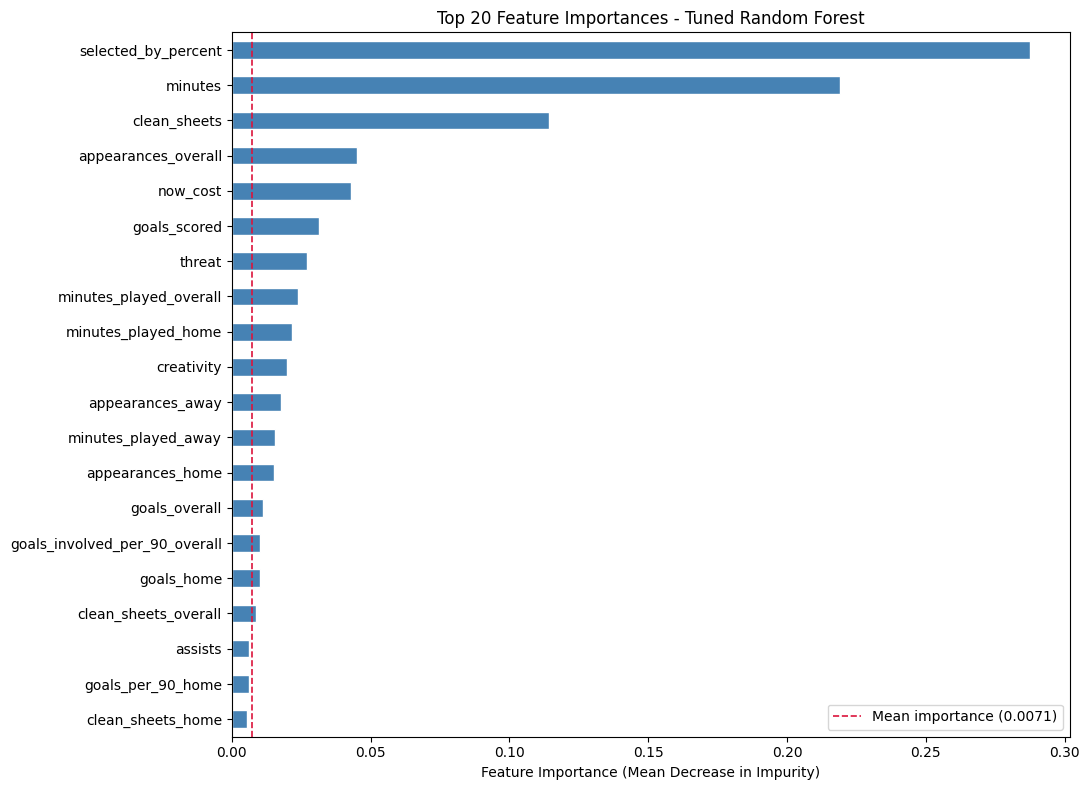

Top 10 features:
selected_by_percent       0.2874
minutes                   0.2192
clean_sheets              0.1142
appearances_overall       0.0450
now_cost                  0.0431
goals_scored              0.0313
threat                    0.0269
minutes_played_overall    0.0240
minutes_played_home       0.0217
creativity                0.0199


In [ ]:
# extract Random Forest best estimator for feature importance
rf_pipeline = rf_search.best_estimator_

# recover feature names from the fitted ColumnTransformer
raw_names     = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_names = [n.replace("num__", "").replace("cat__", "") for n in raw_names]

# extract the importances
rf_model    = rf_pipeline.named_steps["model"]
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top20       = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(11, 8))
top20.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")

# importances to the right of the line are above average importance
# importances to the left of the line are below average
ax.axvline(importances.mean(), color="crimson", linestyle="--", linewidth=1.2,
           label=f"Mean importance ({importances.mean():.4f})")

ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
ax.set_title("Top 20 Feature Importances - Tuned Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.nlargest(10).round(4).to_string())

## Step 3 - Player Value Rankings

**Out-of-fold predictions** are used so each player's predicted score comes from a model that never saw that player during training. This way the model can give an honest, bias-free basis for ranking.

**Value score** = predicted points / player cost 

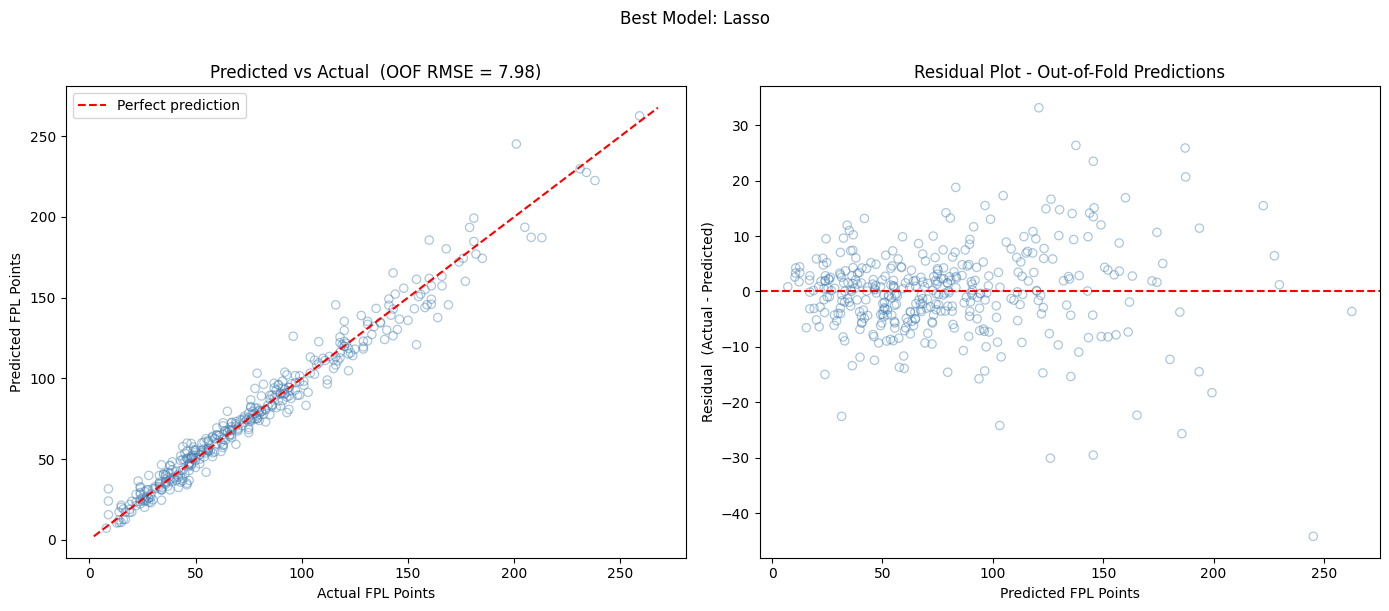

Out-of-fold RMSE: 7.98 FPL points


In [ ]:
# out-of-fold predictions using the best model's hyperparameters
oof_preds = cross_val_predict(best_pipeline, X, y, cv=kf)
oof_rmse  = np.sqrt(np.mean((y.values - oof_preds) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predicted vs Actual
ax = axes[0]
ax.scatter(y, oof_preds, alpha=0.45,
           edgecolors="steelblue", facecolors="none", linewidth=0.9)
lo = min(y.min(), oof_preds.min()) - 5
hi = max(y.max(), oof_preds.max()) + 5

# represents perfect prediction
ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Perfect prediction")

ax.set_xlabel("Actual FPL Points")
ax.set_ylabel("Predicted FPL Points")
ax.set_title(f"Predicted vs Actual  (OOF RMSE = {oof_rmse:.2f})")
ax.legend()

# Residuals
# difference between what model predicted and actual values
ax = axes[1]
residuals = y.values - oof_preds
ax.scatter(oof_preds, residuals, alpha=0.45,
           edgecolors="steelblue", facecolors="none", linewidth=0.9)
ax.axhline(0, color="red", linestyle="--", lw=1.5)
ax.set_xlabel("Predicted FPL Points")
ax.set_ylabel("Residual  (Actual - Predicted)")
ax.set_title("Residual Plot - Out-of-Fold Predictions")

plt.suptitle(f"Best Model: {best_model_name}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f"Out-of-fold RMSE: {oof_rmse:.2f} FPL points")

In [ ]:
id_cols = [c for c in ["full_name", "position", "Current Club", "now_cost", "selected_by_percent"]
           if c in dataset_clean.columns]

ranking_df = (
    dataset_clean[id_cols]
    .loc[X.index]
    .copy()
    .assign(
        cost_m           = lambda df: (df["now_cost"] / 10).round(1),
        actual_points    = y.values,
        predicted_points = oof_preds.round(1),
    )
    .assign(value_score  = lambda df: (df["predicted_points"] / df["cost_m"]).round(2))
    .drop(columns=["now_cost"])
    .rename(columns={"full_name": "Player", "Current Club": "Club", "selected_by_percent": "sel_%"})
    .reset_index(drop=True)
)

# Top 25 by predicted points
top_predicted = ranking_df.sort_values("predicted_points", ascending=False).head(25).copy()
top_predicted.index = range(1, len(top_predicted) + 1)
print("Top 25 by Predicted Points")
display(top_predicted)

# Top 25 by value score
top_value = ranking_df.sort_values("value_score", ascending=False).head(25).copy()
top_value.index = range(1, len(top_value) + 1)
print("Top 25 by Value Score")
display(top_value)

Top 25 by Predicted Points


,Player,position,Club,sel_%,cost_m,actual_points,predicted_points,value_score
1,Mohamed Salah,Forward,Liverpool,33.9,13.2,259,262.6,19.89
2,Sergio Aguero,Forward,Manchester City,42.7,12.0,201,245.2,20.43
3,Sadio Mane,Forward,Liverpool,38.6,10.3,231,229.8,22.31
4,Raheem Sterling,Forward,Manchester City,24.8,11.7,234,227.6,19.45
5,Eden Hazard,Midfielder,Chelsea,27.2,11.0,238,222.5,20.23
6,Raul Jimenez,Forward,Wolverhampton Wanderers,33.4,6.9,181,199.3,28.88
7,Pierre-Emerick Aubameyang,Forward,Arsenal,18.8,10.8,205,193.6,17.93
8,Paul Pogba,Midfielder,Manchester United,33.7,8.6,179,193.5,22.50
9,Virgil Dijk,Defender,Liverpool,32.3,6.7,208,187.3,27.96
10,Andrew Robertson,Defender,Liverpool,33.0,6.7,213,187.1,27.93


Top 25 by Value Score


,Player,position,Club,sel_%,cost_m,actual_points,predicted_points,value_score
1,Jordan Pickford,Goalkeeper,Everton,13.3,4.9,161,149.0,30.41
2,Trent Alexander-Arnold,Defender,Liverpool,26.9,5.8,185,174.3,30.05
3,N'Golo Kante,Midfielder,Chelsea,15.8,4.9,116,145.5,29.69
4,Alisson Becker,Goalkeeper,Liverpool,23.4,5.9,176,174.4,29.56
5,Raul Jimenez,Forward,Wolverhampton Wanderers,33.4,6.9,181,199.3,28.88
6,Ryan Fraser,Midfielder,AFC Bournemouth,23.7,6.4,181,184.7,28.86
7,Matt Doherty,Defender,Wolverhampton Wanderers,21.9,5.3,144,152.2,28.72
8,Virgil Dijk,Defender,Liverpool,32.3,6.7,208,187.3,27.96
9,Andrew Robertson,Defender,Liverpool,33.0,6.7,213,187.1,27.93
10,Rui Patricio,Goalkeeper,Wolverhampton Wanderers,8.0,4.5,118,125.6,27.91


In [ ]:
print("Top 10 Value Picks by Position\n")

display_cols = [c for c in ["Player", "Club", "cost_m", "actual_points",
                             "predicted_points", "value_score", "sel_%"]
                if c in ranking_df.columns]

# drops players that have missing positions after merge
for pos in sorted(ranking_df["position"].dropna().unique()):
    subset = (
        ranking_df[ranking_df["position"] == pos]
        .sort_values("value_score", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    subset.index = range(1, len(subset) + 1)
    print(f"--- {pos} ---")
    display(subset[display_cols])
    print()

Top 10 Value Picks by Position

--- Defender ---


,Player,Club,cost_m,actual_points,predicted_points,value_score,sel_%
1,Trent Alexander-Arnold,Liverpool,5.8,185,174.3,30.05,26.9
2,Matt Doherty,Wolverhampton Wanderers,5.3,144,152.2,28.72,21.9
3,Virgil Dijk,Liverpool,6.7,208,187.3,27.96,32.3
4,Andrew Robertson,Liverpool,6.7,213,187.1,27.93,33.0
5,Lucas Digne,Everton,5.4,158,143.9,26.65,10.2
6,Ricardo Pereira,Leicester City,5.3,146,136.6,25.77,10.6
7,Willy Boly,Wolverhampton Wanderers,4.7,120,119.8,25.49,6.1
8,Aymeric Laporte,Manchester City,6.3,177,160.1,25.41,16.7
9,Michael Keane,Everton,4.8,129,119.5,24.90,4.3
10,Cesar Azpilicueta,Chelsea,6.4,158,155.0,24.22,9.6



--- Forward ---


,Player,Club,cost_m,actual_points,predicted_points,value_score,sel_%
1,Raul Jimenez,Wolverhampton Wanderers,6.9,181,199.3,28.88,33.4
2,Callum Wilson,AFC Bournemouth,6.9,168,180.3,26.13,20.3
3,Ayoze Perez,Newcastle United,6.1,141,145.3,23.82,3.4
4,Joshua King,AFC Bournemouth,6.4,141,149.1,23.30,5.1
5,David Brooks,AFC Bournemouth,5.0,123,115.8,23.16,3.6
6,Sadio Mane,Liverpool,10.3,231,229.8,22.31,38.6
7,Gerard Deulofeu,Watford,5.7,133,127.1,22.30,7.2
8,Ashley Barnes,Burnley,5.6,122,118.6,21.18,2.1
9,Aleksandar Mitrovic,Fulham,6.3,134,132.1,20.97,10.8
10,Sergio Aguero,Manchester City,12.0,201,245.2,20.43,42.7



--- Goalkeeper ---


,Player,Club,cost_m,actual_points,predicted_points,value_score,sel_%
1,Jordan Pickford,Everton,4.9,161,149.0,30.41,13.3
2,Alisson Becker,Liverpool,5.9,176,174.4,29.56,23.4
3,Rui Patricio,Wolverhampton Wanderers,4.5,118,125.6,27.91,8.0
4,Lukasz Fabianski,West Ham United,4.7,143,126.4,26.89,14.3
5,Ben Foster,Watford,4.6,129,123.0,26.74,8.5
6,Martin Dubravka,Newcastle United,5.0,131,133.5,26.70,1.0
7,Neil Etheridge,Cardiff City,4.6,154,120.9,26.28,10.2
8,Kasper Schmeichel,Leicester City,5.0,120,129.6,25.92,4.7
9,Kepa Arrizabalaga,Chelsea,5.4,142,139.1,25.76,4.9
10,Hugo Lloris,Tottenham Hotspur,5.4,145,130.2,24.11,6.2



--- Midfielder ---


,Player,Club,cost_m,actual_points,predicted_points,value_score,sel_%
1,N'Golo Kante,Chelsea,4.9,116,145.5,29.69,15.8
2,Ryan Fraser,AFC Bournemouth,6.4,181,184.7,28.86,23.7
3,Aaron Wan-Bissaka,Crystal Palace,4.6,120,119.9,26.07,26.3
4,Andros Townsend,Crystal Palace,5.6,135,143.3,25.59,3.5
5,Victor Camarasa,Cardiff City,4.4,106,111.3,25.30,2.2
6,James McArthur,Crystal Palace,4.9,121,121.7,24.84,3.4
7,Nathan Redmond,Southampton,5.5,137,134.7,24.49,6.9
8,Luka Milivojevic,Crystal Palace,6.5,166,157.3,24.20,10.6
9,Ashley Westwood,Burnley,4.6,111,111.1,24.15,3.1
10,Gylfi Sigurdsson,Everton,7.4,182,177.0,23.92,8.3


In [ ]:
print("Top 10 by Predicted Points by Position\n")

display_cols = [c for c in ["Player", "Club", "cost_m", "actual_points",
                             "predicted_points", "value_score", "sel_%"]
                if c in ranking_df.columns]

for pos in sorted(ranking_df["position"].dropna().unique()):
    subset = (
        ranking_df[ranking_df["position"] == pos]
        .sort_values("predicted_points", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    subset.index = range(1, len(subset) + 1)
    print(f"--- {pos} ---")
    display(subset[display_cols])
    print()

Top 10 by Predicted Points by Position

--- Defender ---


,Player,Club,cost_m,actual_points,predicted_points,value_score,sel_%
1,Virgil Dijk,Liverpool,6.7,208,187.3,27.96,32.3
2,Andrew Robertson,Liverpool,6.7,213,187.1,27.93,33.0
3,Trent Alexander-Arnold,Liverpool,5.8,185,174.3,30.05,26.9
4,Aymeric Laporte,Manchester City,6.3,177,160.1,25.41,16.7
5,Cesar Azpilicueta,Chelsea,6.4,158,155.0,24.22,9.6
6,Matt Doherty,Wolverhampton Wanderers,5.3,144,152.2,28.72,21.9
7,Marcos Alonso,Chelsea,6.2,161,145.9,23.53,22.1
8,Lucas Digne,Everton,5.4,158,143.9,26.65,10.2
9,Ricardo Pereira,Leicester City,5.3,146,136.6,25.77,10.6
10,Kyle Walker,Manchester City,6.4,150,135.9,21.23,12.1



--- Forward ---


,Player,Club,cost_m,actual_points,predicted_points,value_score,sel_%
1,Mohamed Salah,Liverpool,13.2,259,262.6,19.89,33.9
2,Sergio Aguero,Manchester City,12.0,201,245.2,20.43,42.7
3,Sadio Mane,Liverpool,10.3,231,229.8,22.31,38.6
4,Raheem Sterling,Manchester City,11.7,234,227.6,19.45,24.8
5,Raul Jimenez,Wolverhampton Wanderers,6.9,181,199.3,28.88,33.4
6,Pierre-Emerick Aubameyang,Arsenal,10.8,205,193.6,17.93,18.8
7,Roberto Firmino,Liverpool,9.3,160,185.7,19.97,14.2
8,Callum Wilson,AFC Bournemouth,6.9,168,180.3,26.13,20.3
9,Jamie Vardy,Leicester City,9.0,174,172.1,19.12,10.3
10,Alexandre Lacazette,Arsenal,9.4,166,163.2,17.36,11.4



--- Goalkeeper ---


,Player,Club,cost_m,actual_points,predicted_points,value_score,sel_%
1,Alisson Becker,Liverpool,5.9,176,174.4,29.56,23.4
2,Jordan Pickford,Everton,4.9,161,149.0,30.41,13.3
3,Kepa Arrizabalaga,Chelsea,5.4,142,139.1,25.76,4.9
4,David Gea,Manchester United,5.7,120,135.3,23.74,16.2
5,Martin Dubravka,Newcastle United,5.0,131,133.5,26.70,1.0
6,Hugo Lloris,Tottenham Hotspur,5.4,145,130.2,24.11,6.2
7,Kasper Schmeichel,Leicester City,5.0,120,129.6,25.92,4.7
8,Lukasz Fabianski,West Ham United,4.7,143,126.4,26.89,14.3
9,Rui Patricio,Wolverhampton Wanderers,4.5,118,125.6,27.91,8.0
10,Ben Foster,Watford,4.6,129,123.0,26.74,8.5



--- Midfielder ---


,Player,Club,cost_m,actual_points,predicted_points,value_score,sel_%
1,Eden Hazard,Chelsea,11.0,238,222.5,20.23,27.2
2,Paul Pogba,Manchester United,8.6,179,193.5,22.50,33.7
3,Ryan Fraser,AFC Bournemouth,6.4,181,184.7,28.86,23.7
4,Gylfi Sigurdsson,Everton,7.4,182,177.0,23.92,8.3
5,Wilfried Zaha,Crystal Palace,7.0,143,165.3,23.61,15.6
6,Bernardo Silva,Manchester City,7.8,154,161.3,20.68,13.6
7,Luka Milivojevic,Crystal Palace,6.5,166,157.3,24.20,10.6
8,Christian Eriksen,Tottenham Hotspur,9.2,161,157.3,17.10,7.7
9,Leroy Sane,Manchester City,9.3,156,152.1,16.35,7.3
10,N'Golo Kante,Chelsea,4.9,116,145.5,29.69,15.8
